In [66]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report as cr
from sklearn.metrics import confusion_matrix as cm
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import joblib as jb 
from sklearn.model_selection import GridSearchCV 
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

Loading data 

In [67]:
dataset = pd.read_csv('Mall_Customers.csv')
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


Preprocessing the Pipeline

In [68]:
#label encoding
le = LabelEncoder()
dataset['Genre'] = le.fit_transform(dataset['Genre'])
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40
...,...,...,...,...,...
195,196,0,35,120,79
196,197,0,45,126,28
197,198,1,32,126,74
198,199,1,32,137,18


In [69]:
preprocessing_pipe = Pipeline([
    ('drop_id', ColumnTransformer(
        [('drop', 'drop', [0])], 
        remainder='passthrough'
    )),
    ('imputer', SimpleImputer(strategy='mean')),  
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components = 2))
])

processed_data = preprocessing_pipe.fit_transform(dataset)
dataset = pd.DataFrame(processed_data, columns=['PC1', 'PC2'])
original_data = dataset.copy()

Exploraory Data Analysis

/var/folders/_g/3jm_h3c15k34rwm0w2rtr0wh0000gn/T/ipykernel_98712/2120919673.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset[i])


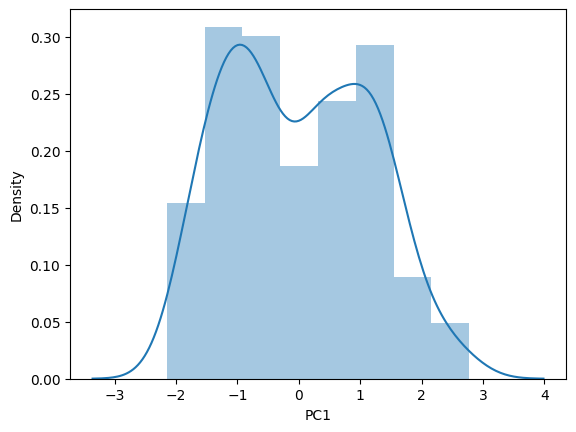

/var/folders/_g/3jm_h3c15k34rwm0w2rtr0wh0000gn/T/ipykernel_98712/2120919673.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset[i])


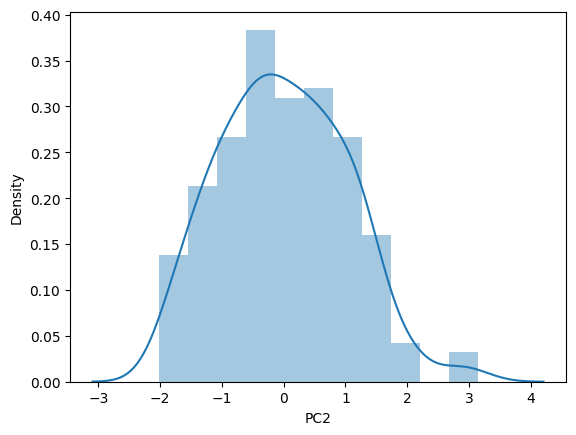

In [70]:
#distrubution plot
features = dataset.columns
for i in features:
    sns.distplot(dataset[i])
    plt.show()

Text(0, 0.5, 'Values')

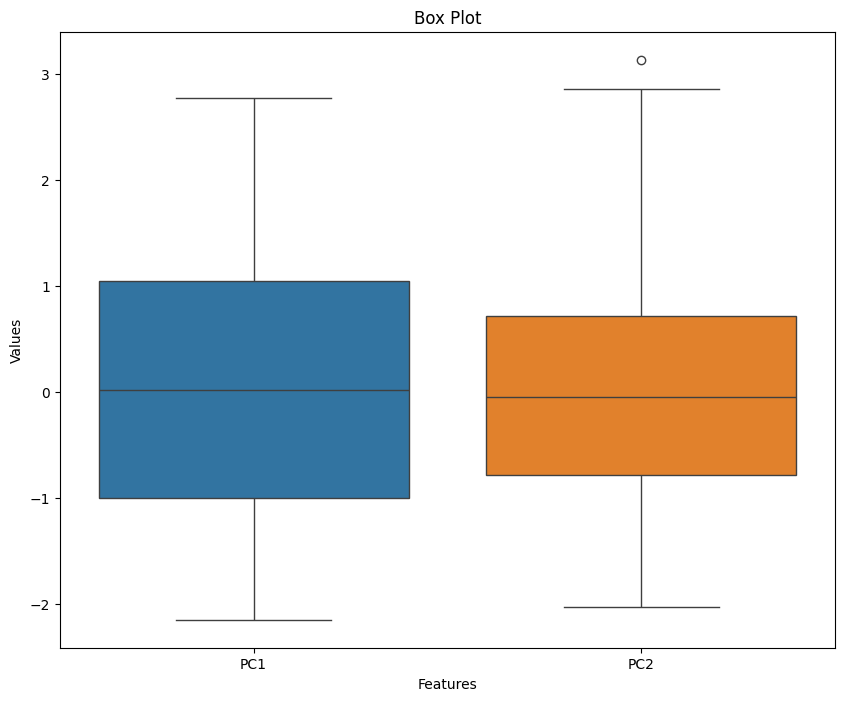

In [71]:
#box plots
plt.figure(figsize=(10, 8))
sns.boxplot(data = dataset)
plt.title('Box Plot')
plt.xlabel('Features')
plt.ylabel('Values')

In [73]:
#remove outliers
Q1 = dataset.quantile(0.25)
Q3 = dataset.quantile(0.75)
IQR = Q3 - Q1
dataset = dataset[~((dataset < (Q1 - 1.5 * IQR)) | (dataset > (Q3 + 1.5 * IQR))).any(axis=1)]

Q1_ = original_data.quantile(0.25)
Q3_ = original_data.quantile(0.75)
IQR_ = Q3_ - Q1_
original_data = original_data[~((original_data < (Q1_ - 1.5 * IQR_)) | (original_data > (Q3_ + 1.5 * IQR_))).any(axis=1)]

Text(0, 0.5, 'Values')

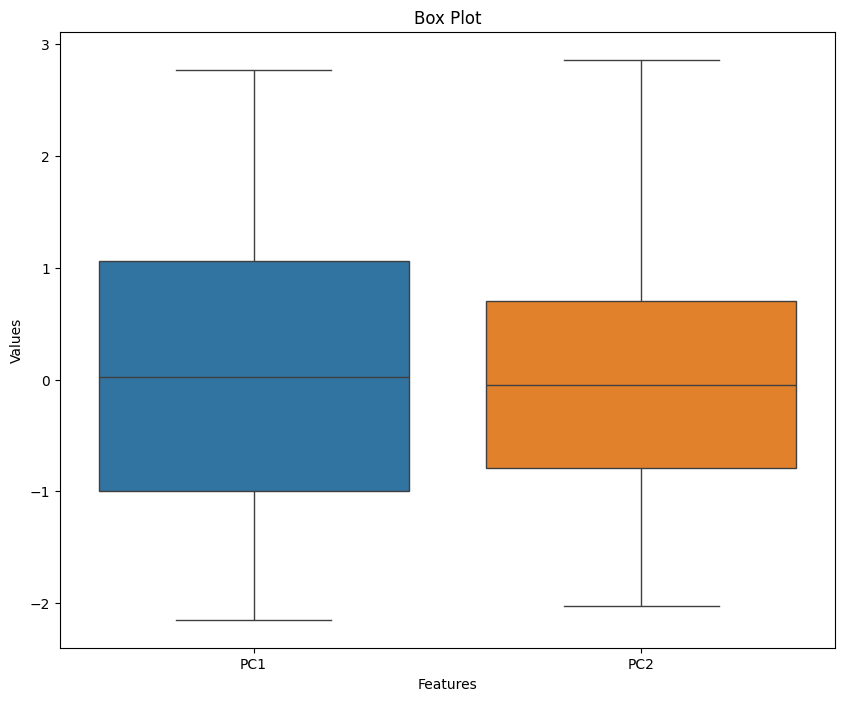

In [74]:
#box plots after removing outliers
plt.figure(figsize=(10, 8))
sns.boxplot(data = dataset)
plt.title('Box Plot')
plt.xlabel('Features')
plt.ylabel('Values')

In [75]:
#correlation matrix
correlation_matrix = dataset.corr()
correlation_matrix

,PC1,PC2
PC1,1.000000,0.014496
PC2,0.014496,1.000000


K Means Clustering Pipeline

In [76]:
clustering_pipe = Pipeline([
    ('kmeans', KMeans(random_state=42))
])

In [77]:
param_grid = {
    'kmeans__n_clusters': range(2, 11),
    'kmeans__init': ['k-means++', 'random'],
    'kmeans__max_iter': [100, 300, 500]
}

grid_search = GridSearchCV(clustering_pipe, param_grid, cv=5)
grid_search.fit(dataset)

print('Best Parameters: ', grid_search.best_params_)
print('Best Score: ', grid_search.best_score_)

Best Parameters:  {'kmeans__init': 'random', 'kmeans__max_iter': 100, 'kmeans__n_clusters': 10}
Best Score:  -21.640178605926653


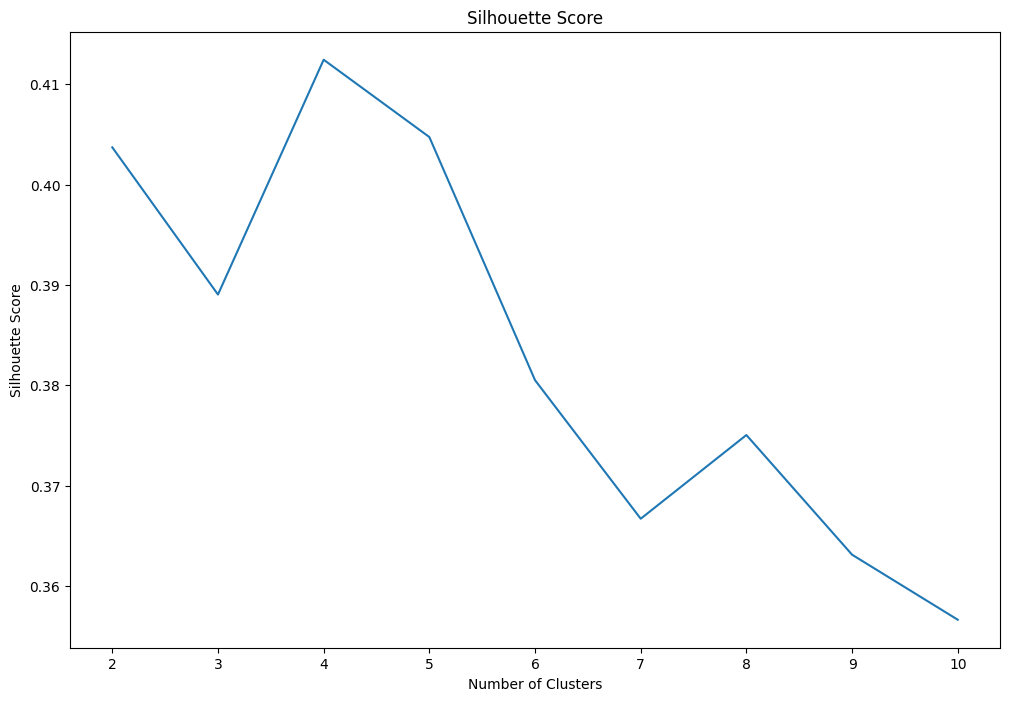

In [78]:
# Silhouette analysis (identical logic)
silhouette_scores = []
for i in range(2, 11):
    clustering_pipe.set_params(kmeans__n_clusters=i)
    clustering_pipe.fit(dataset)
    silhouette_scores.append(silhouette_score(dataset, clustering_pipe.named_steps['kmeans'].labels_))

plt.figure(figsize=(12, 8))
plt.plot(range(2, 11), silhouette_scores)
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

Text(0.5, 1.0, 'Scatter Plot')

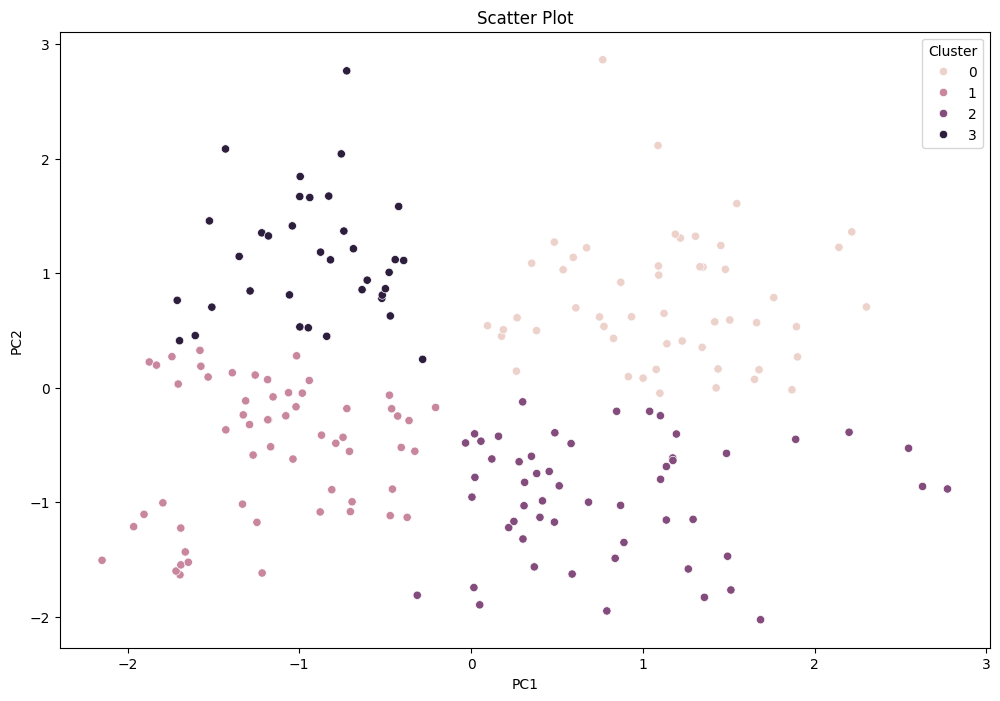

In [120]:
#final clustering with silhoutte scoren using pipeline 

clustering_pipe.set_params(kmeans__n_clusters = 4)
clustering_pipe.fit(dataset)
dataset['Cluster'] = clustering_pipe.named_steps['kmeans'].labels_
original_data['Cluster'] = clustering_pipe.named_steps['kmeans'].labels_

#plot clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x = 'PC1', y = 'PC2', hue = 'Cluster', data = dataset)
plt.title('Scatter Plot')

Classification Pipelines

In [121]:
classification_pipes = {
    'decision_tree': Pipeline([
        ('classifier', DecisionTreeClassifier())
    ]),
    'logistic_regression': Pipeline([
        ('classifier', LogisticRegression(C=0.1))
    ]),
    'random_forest': Pipeline([
        ('classifier', RandomForestClassifier())
    ])
}

In [123]:
X = original_data.drop('Cluster', axis=1)
y = original_data['Cluster']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()  
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)

1️⃣ Decision Tree

In [124]:
dt_pipe = classification_pipes['decision_tree']
dt_pipe.fit(X_train, y_train)
y_pred = dt_pipe.predict(X_test)

print('Accuracy: ', accuracy_score(y_test, y_pred) * 100)

Accuracy:  97.5


In [125]:
#classification report
print(cr(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       1.00      1.00      1.00        10
           2       1.00      0.91      0.95        11
           3       1.00      1.00      1.00         8

    accuracy                           0.97        40
   macro avg       0.98      0.98      0.98        40
weighted avg       0.98      0.97      0.97        40



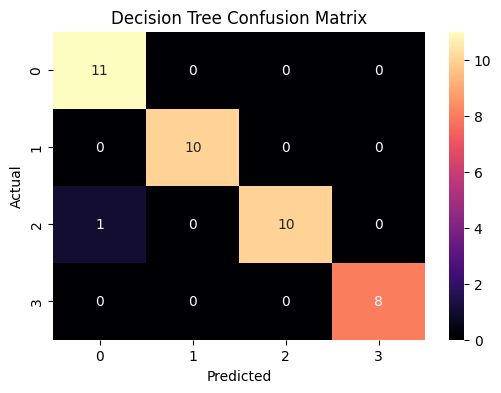

In [126]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm(y_test, y_pred), annot=True, cmap='magma')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

2️⃣ Logistic Regression

In [127]:
lr_pipe = classification_pipes['logistic_regression']
lr_pipe.fit(X_train, y_train)
y_pred = lr_pipe.predict(X_test)

print('Accuracy: ', accuracy_score(y_test, y_pred) * 100)

Accuracy:  95.0


In [128]:
#classification report
print(cr(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.83      1.00      0.91        10
           2       1.00      1.00      1.00        11
           3       1.00      0.75      0.86         8

    accuracy                           0.95        40
   macro avg       0.96      0.94      0.94        40
weighted avg       0.96      0.95      0.95        40



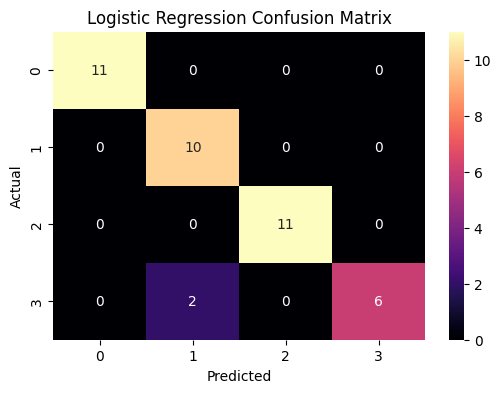

In [129]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm(y_test, y_pred), annot=True, cmap='magma')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

3️⃣ Random Forest

In [130]:
rf_pipe = classification_pipes['random_forest']
rf_pipe.fit(X_train, y_train)
y_pred = rf_pipe.predict(X_test)


In [131]:
print('Accuracy: ', accuracy_score(y_test, y_pred) * 100)

Accuracy:  97.5


In [132]:
print(cr(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       1.00      1.00      1.00        10
           2       1.00      0.91      0.95        11
           3       1.00      1.00      1.00         8

    accuracy                           0.97        40
   macro avg       0.98      0.98      0.98        40
weighted avg       0.98      0.97      0.97        40



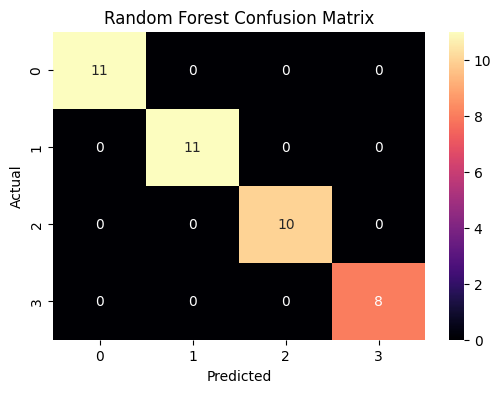

In [106]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm(y_test, y_pred), annot=True, cmap='magma')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()